In [7]:
import numpy as np

Process is described by $$dS_t = \mu S_t dt + \sigma S_t dt + S_{t^{-}} (J-1) dN_t$$ where $\ln(J) \sim N(\mu_J, \sigma_J^2)$ and $N_t \sim \mathrm{Pois}(\lambda t)$.

In [63]:
S0 = 100
T = 1
N = 252
dt = T/N

mu = 0.02  #drift
sigma = 0.2 #annual volatility
lam = 0 # parameter of Poisson process
mu_J, sigma_J = -0.03, 0.1 # parameters of lognormal scaling factor in jump term

n_paths = 50_000


In [64]:
Z = np.random.normal(size = (n_paths, N))   # ordinary movement
jump_counts = np.random.poisson(lam*dt, (n_paths, N)) # counting jumps
jump_sizes = np.random.normal(mu_J, sigma_J, (n_paths, N)) # jump sizes
J = np.exp(jump_sizes) # jump multiplier

In [65]:
# integrating, have following multiplicative factors

diffusion = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
jump_factor = J ** jump_counts

In [66]:
# price paths

S = np.zeros((n_paths, N+1))
S[:,0] = S0
S[:,1:] = S0*np.cumprod(np.exp(diffusion)*jump_factor, axis = 1)

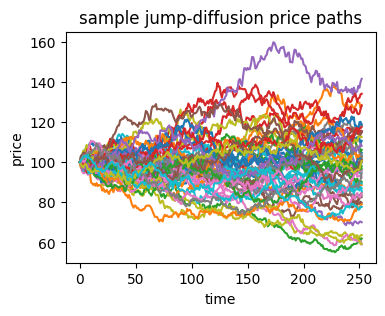

In [67]:
# plot some paths

import matplotlib.pyplot as plt

plt.figure(figsize = (4,3))

for i in range(50):
    plt.plot(S[i])

plt.title("sample jump-diffusion price paths")
plt.xlabel("time")
plt.ylabel("price")
plt.show()


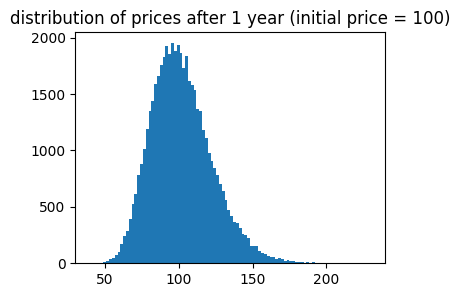

In [71]:
plt.figure(figsize = (4,3))

plt.hist(S[:,-1], bins = 100)
plt.title("distribution of prices after 1 year (initial price = 100)")
plt.show()

In [69]:
# options pricing

K = 100 # strike
T = 252 # number of timesteps to maturity
r = 0 # risk-free rate

call_payout = np.maximum(S[:,T] - K, 0)
put_payout = np.maximum(K - S[:,T], 0)

C0 = call_payout.mean()
P0 = put_payout.mean()

In [70]:
C0,P0

(np.float64(9.153386474421897), np.float64(7.106278241077639))